In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string

In [2]:
df = pd.read_csv(r"C:\Users\AKASH TOMER\Downloads\spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)
df.rename(columns={'v1':'target','v2':'text'}, inplace=True)

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [5]:
df = df.drop_duplicates(keep='first')

In [6]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(str(x).split()))
df['num_sentences'] = df['text'].apply(lambda x: str(x).count('.') + str(x).count('!') + str(x).count('?'))

In [7]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,8
1,0,Ok lar... Joking wif u oni...,29,6,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,0,U dun say so early hor... U c already then say...,49,11,6
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0


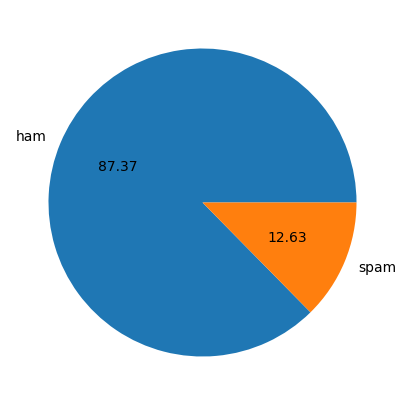

In [8]:
plt.figure(figsize=(5,5))
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct='%0.2f')
plt.show()

In [9]:
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to C:\Users\AKASH
[nltk_data]     TOMER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\AKASH
[nltk_data]     TOMER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [10]:
def transform_text(text):
    text = str(text).lower()
    words = text.split()
    
    words = [w for w in words if w.isalnum()]
    words = [w for w in words if w not in stop_words]
    words = [ps.stem(w) for w in words]
    
    return words

df['transform_text'] = df['text'].apply(transform_text)

In [11]:
df['clean_text'] = df['transform_text'].apply(lambda x: " ".join(x))

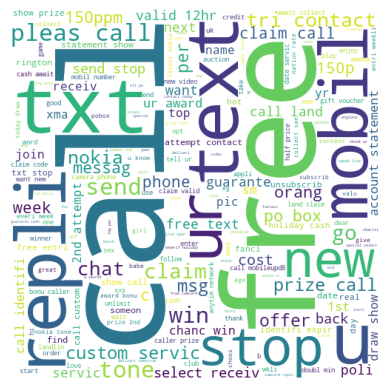

In [12]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, background_color='white')

spam_wc = wc.generate(df[df['target']==1]['clean_text'].str.cat(sep=" "))
plt.imshow(spam_wc)
plt.axis('off')
plt.show()

In [13]:
spam_corpus = []

for msg in df[df['target']==1]['transform_text']:
    spam_corpus.extend(msg)

In [14]:
from collections import Counter

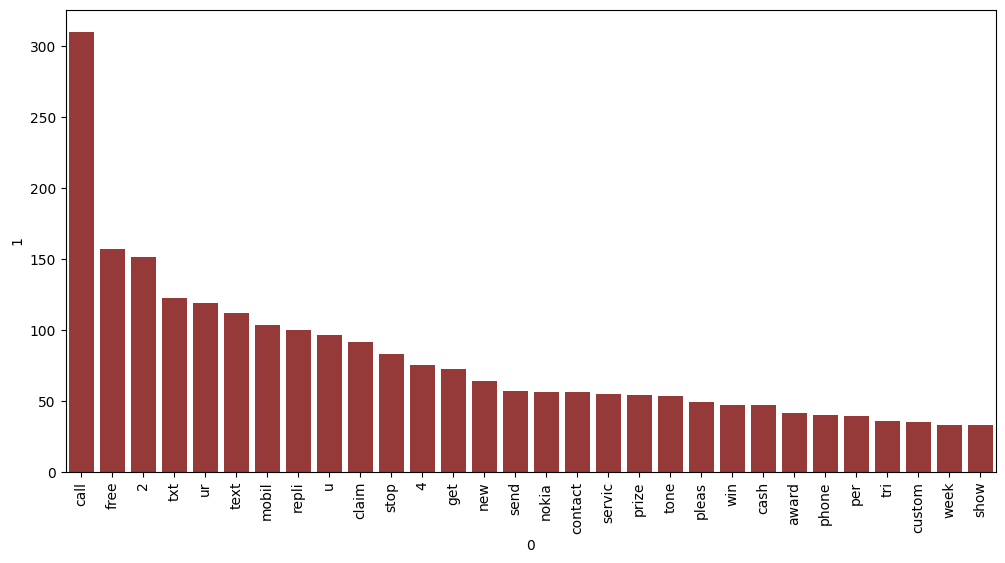

In [15]:
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

plt.figure(figsize=(12,6))
sns.barplot(x=top_words[0], y=top_words[1],color='brown')

plt.xticks(rotation='vertical')
plt.show()

In [16]:
ham_corpus = []

for msg in df[df['target']==0]['transform_text']:
    ham_corpus.extend(msg)

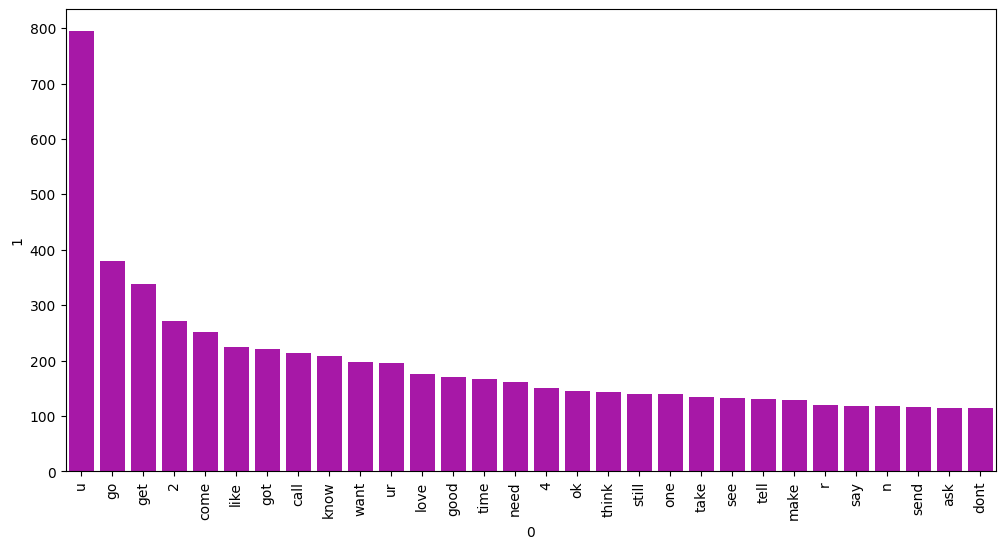

In [17]:
top_words1 = pd.DataFrame(Counter(ham_corpus).most_common(30))

plt.figure(figsize=(12,6))
sns.barplot(x=top_words1[0], y=top_words1[1],color='m')

plt.xticks(rotation='vertical')
plt.show()

In [63]:
from sklearn.feature_extraction.text import CountVectorizer ,TfidfVectorizer
cv=CountVectorizer()
tf=TfidfVectorizer()
x=tf.fit_transform(df['clean_text']).toarray()
x.shape

(5169, 5643)

In [19]:
y=df['target'].values 
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [20]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [21]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB 
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score
gn=GaussianNB()
mn=MultinomialNB()
bn=BernoulliNB()

accuracy is 79.01353965183753
precision_score is 38.81987577639752


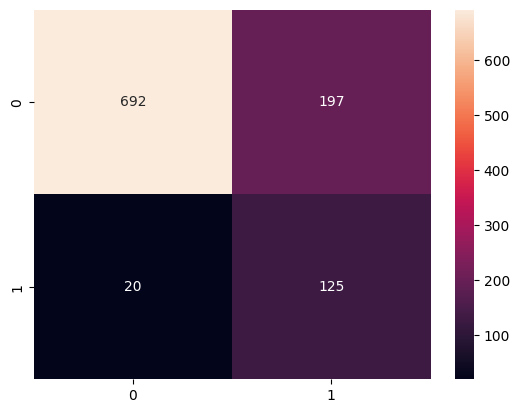

In [22]:
gn.fit(x_train,y_train)
y_pred1=gn.predict(x_test)
print("accuracy is",accuracy_score(y_test,y_pred1)*100)
print("precision_score is" ,precision_score(y_test,y_pred1)*100)
sns.heatmap(confusion_matrix(y_test,y_pred1),fmt='d',annot=True)
plt.show()

accuracy is 94.77756286266924
precision_score is 100.0


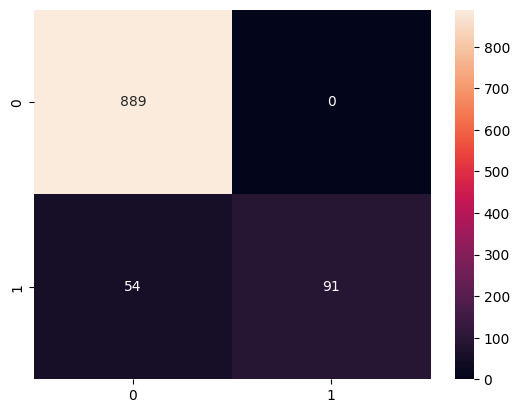

In [23]:
mn.fit(x_train,y_train)
y_pred2=mn.predict(x_test)
print("accuracy is",accuracy_score(y_test,y_pred2)*100)
print("precision_score is" ,precision_score(y_test,y_pred2)*100)
sns.heatmap(confusion_matrix(y_test,y_pred2),fmt='d',annot=True)
plt.show()

accuracy is 96.61508704061895
precision_score is 97.41379310344827


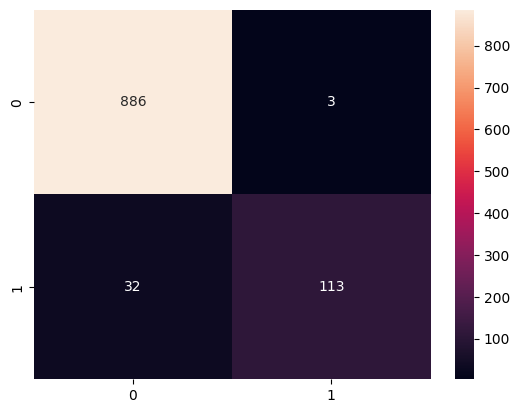

In [24]:
bn.fit(x_train,y_train)
y_pred3=bn.predict(x_test)
print("accuracy is",accuracy_score(y_test,y_pred3)*100)
print("precision_score is" ,precision_score(y_test,y_pred3)*100)
sns.heatmap(confusion_matrix(y_test,y_pred3),fmt='d',annot=True)
plt.show()

In [38]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import BaggingClassifier 
from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.ensemble import AdaBoostClassifier 
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, precision_score

In [39]:
dc=DecisionTreeClassifier(max_depth=5) 
lr=LogisticRegression(solver='liblinear',penalty='l1') 
kn=KNeighborsClassifier() 
svc=SVC(kernel='sigmoid',gamma=1.0)
rf=RandomForestClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gb=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)

In [48]:
models= {'DCT':dc,'LR':lr,'KNN':kn,'SVC':svc,'RF':rf,'BC':bc,'ABC':abc,'etc':etc,'GB':gb,'XGB':xgb}

In [49]:
def train_classfier(clf,x_train,y_train,x_test,y_test) :
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred) 
    return accuracy,precision

In [50]:
accuracy_list=[]
precision_list=[]
for name,model in models.items():
    current_accuracy,currect_precision=train_classfier(model,x_train,y_train,x_test,y_test) 
    
    print("For ",name)
    print("ACcuracy ",current_accuracy)
    print("Precison ",currect_precision) 
    
    accuracy_list.append(current_accuracy)
    precision_list.append(currect_precision)

For  DCT
ACcuracy  0.9332688588007737
Precison  0.8392857142857143


C:\Users\AKASH TOMER\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\AKASH TOMER\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  LR
ACcuracy  0.9439071566731141
Precison  0.9065420560747663
For  KNN
ACcuracy  0.8926499032882012
Precison  1.0
For  SVC
ACcuracy  0.965183752417795
Precison  0.9291338582677166
For  RF
ACcuracy  0.9642166344294004
Precison  0.990909090909091
For  BC
ACcuracy  0.9526112185686654
Precison  0.8692307692307693
For  ABC
ACcuracy  0.9177949709864603
Precison  0.8191489361702128
For  etc
ACcuracy  0.9700193423597679
Precison  0.9913793103448276
For  GB
ACcuracy  0.9477756286266924
Precison  0.9026548672566371
For  XGB
ACcuracy  0.9622823984526112
Precison  0.9140625


In [52]:
performance_df=pd.DataFrame({"Algorithm":models.keys(),'Accuracy': accuracy_list,'Precision': precision_list})
print(performance_df.sort_values(by='Precision', ascending=False))

  Algorithm  Accuracy  Precision
2       KNN  0.892650   1.000000
7       etc  0.970019   0.991379
4        RF  0.964217   0.990909
3       SVC  0.965184   0.929134
9       XGB  0.962282   0.914062
1        LR  0.943907   0.906542
8        GB  0.947776   0.902655
5        BC  0.952611   0.869231
0       DCT  0.933269   0.839286
6       ABC  0.917795   0.819149


In [55]:
df_melted = performance_df.melt(id_vars="Algorithm",var_name="Metric",value_name="Value")

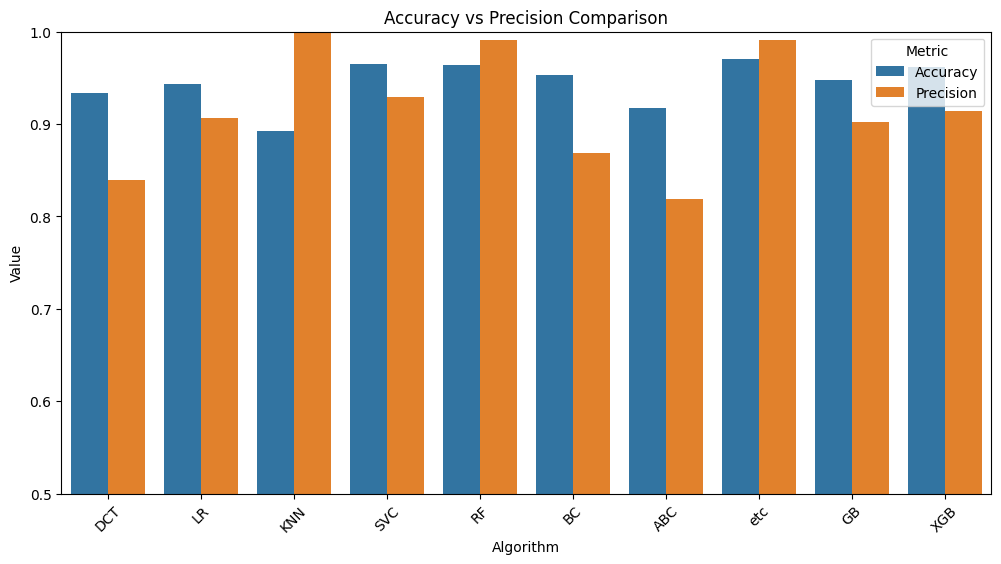

In [56]:
plt.figure(figsize=(12,6))
sns.barplot(x="Algorithm", y="Value",hue="Metric",data=df_melted)

plt.xticks(rotation=45)
plt.ylim(0.5, 1.0)
plt.title("Accuracy vs Precision Comparison")

plt.show()

In [62]:
import pickle
pickle.dump(tf, open('vectorizer.pkl', 'wb'))
pickle.dump(mn, open('model.pkl', 'wb'))